In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tabulate import tabulate

In [ ]:
# Veri oluşturma fonksiyonu
def create_sample_A(size=25):
    mat = np.zeros((size, size), dtype=np.uint8)
    points = np.random.choice(size*size, 2, replace=False)
    coords = np.array([[p//size, p%size] for p in points])
    mat[coords[0,0], coords[0,1]] = 1
    mat[coords[1,0], coords[1,1]] = 1
    dist = np.linalg.norm(coords[0] - coords[1])
    return mat, dist

In [ ]:
# Veri seti oluşturma ve okuma
filename = "problemA_cnn.csv"
try:
    df = pd.read_csv(filename)
    print("CSV'den veri okundu.")
except FileNotFoundError:
    np.random.seed(42)
    X, y = [], []
    for _ in range(1000):
        mat, dist = create_sample_A(size=25)
        X.append(mat)
        y.append(dist)
    X = np.array(X)
    y = np.array(y).astype(np.float32)
    X_flat = X.reshape(1000, -1)
    df = pd.DataFrame(X_flat, columns=[i for i in range(X_flat.shape[1])])
    df["label"] = y
    df.to_csv(filename, index=False)
    print(f"{filename} dosyası kaydedildi.")

problemA_cnn.csv dosyası kaydedildi.


In [4]:
# Veriyi uygun hale getir
X = df.drop("label", axis=1).values.reshape(-1, 25, 25, 1)
y = df["label"].values.astype(np.float32)

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=200, random_state=42)

In [ ]:
# CNN model fonksiyonu
def build_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(25, 25, 1)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

In [ ]:
# Çeyrek, yarım ve tam eğitim seti ile denemeler
train_sizes = [0.25, 0.5, 1.0]
results_table = []
histories = []

for train_fraction in train_sizes:
    n_train = int(X_train_full.shape[0] * train_fraction)
    X_train = X_train_full[:n_train]
    y_train = y_train_full[:n_train]

    model = build_cnn()
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )
    histories.append(history)
    test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
    results_table.append([n_train, test_loss, test_mae])

print("\nSonuç Tablosu:")
print(tabulate(results_table, headers=["Eğitim Kümesi", "Test MSE", "Test MAE"], tablefmt="github"))



--- Eğitim veri oranı: 25% (200 örnek) ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Eğitim veri oranı: 50% (400 örnek) ---

--- Eğitim veri oranı: 100% (800 örnek) ---

Sonuç Tablosu:
|   Eğitim Kümesi |   Test MSE |   Test MAE |
|-----------------|------------|------------|
|             200 |    34.8021 |    4.79963 |
|             400 |    30.492  |    4.49295 |
|             800 |    29.424  |    4.38714 |


In [7]:
# Son eğitim (tam veriyle) sonrası analizler
best_model = build_cnn()
best_model.fit(
    X_train_full, y_train_full,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


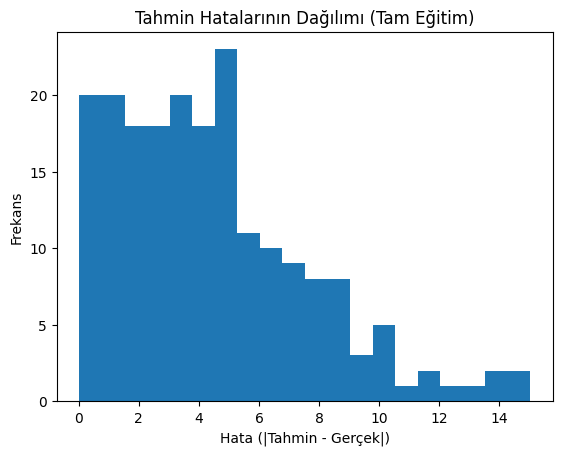

In [8]:
y_pred = best_model.predict(X_test).flatten()
abs_errors = np.abs(y_pred - y_test)

# Hataların dağılımı
plt.figure()
plt.hist(abs_errors, bins=20)
plt.title("Tahmin Hatalarının Dağılımı (Tam Eğitim)")
plt.xlabel("Hata (|Tahmin - Gerçek|)")
plt.ylabel("Frekans")
plt.show()



--- En Başarılı 5 Test Örneği ---


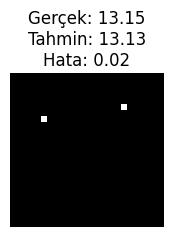

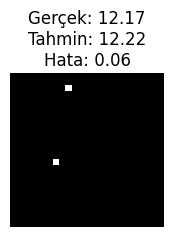

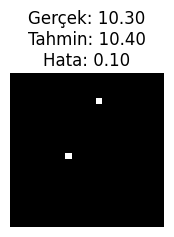

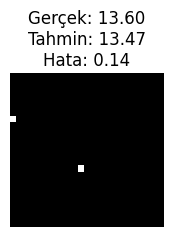

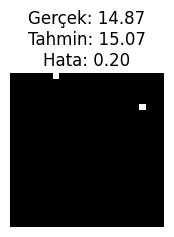


--- En Kötü 5 Test Örneği ---


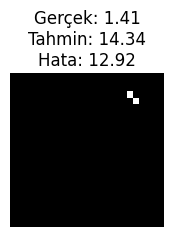

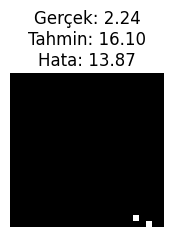

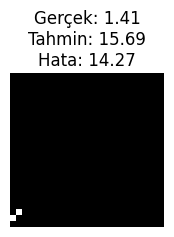

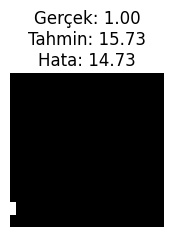

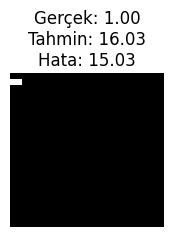

In [9]:
# En iyi ve en kötü 5 test örneği
best_idx = np.argsort(abs_errors)[:5]
worst_idx = np.argsort(abs_errors)[-5:]

print("\n--- En Başarılı 5 Test Örneği ---")
for idx in best_idx:
    plt.figure(figsize=(2,2))
    plt.imshow(X_test[idx].squeeze(), cmap='gray')
    plt.title(f"Gerçek: {y_test[idx]:.2f}\nTahmin: {y_pred[idx]:.2f}\nHata: {abs_errors[idx]:.2f}")
    plt.axis('off')
    plt.show()

print("\n--- En Kötü 5 Test Örneği ---")
for idx in worst_idx:
    plt.figure(figsize=(2,2))
    plt.imshow(X_test[idx].squeeze(), cmap='gray')
    plt.title(f"Gerçek: {y_test[idx]:.2f}\nTahmin: {y_pred[idx]:.2f}\nHata: {abs_errors[idx]:.2f}")
    plt.axis('off')
    plt.show()

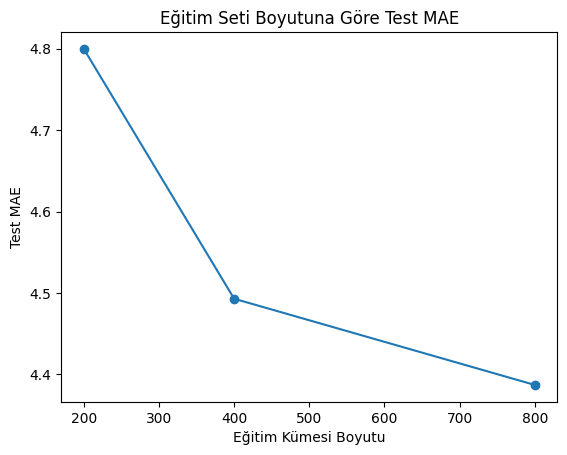

In [10]:
# Eğitim seti boyutu - Test MAE grafiği
train_counts = [row[0] for row in results_table]
test_maes = [row[-1] for row in results_table]
plt.figure()
plt.plot(train_counts, test_maes, marker='o')
plt.title("Eğitim Seti Boyutuna Göre Test MAE")
plt.xlabel("Eğitim Kümesi Boyutu")
plt.ylabel("Test MAE")
plt.show()